In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from datetime import date, datetime, timedelta, timezone
from astroquery.jplhorizons import Horizons
import astropy.units as u
import pandas as pd
import xarray as xr
from tqdm import tqdm
import calendar
from matplotlib.patches import Rectangle
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, get_body, get_sun
from astropy.time import Time
import multiprocessing

from utils import *

%load_ext autoreload
%autoreload 2

ephempath = '/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool/ephemeris-tables/'
toipath = '/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Functions bank

In [117]:
date = now.strftime('%Y-%m-%d')
date

'2026-06-21'

In [110]:
def read_solar_ephemeris(datestr=None):
    '''
    Read pre-generated lookup table of solar ephemerides from Keck II. 
    User can input an optional date string (YYY-MM-DD) to pull ephemerides
    from this date; otherwise, the code pulls ephemerides from today.
    '''
    
    # Parse date if given by user
    if datestr is not None:
        date = datetime.strptime(datestr, '%Y-%m-%d')
        year = date.strftime('%Y')
    
    # Otherwise, use today's date
    else:
        now = datetime.now()
        date = now.strftime('%Y-%m-%d')
        year = now.strftime('%Y')
        
        
    # Read in solar ephemeris table from matching year
    ephem = pd.read_csv(f'{ephempath}/twilight_ephemerides_keckII_{year}.csv')
    
    
    # Identify row of ephemeris table that matches date
    try: 
        
        ix = ephem.index[ephem['Date'] == date].tolist()

        try: 
            assert len(ix)==1
            ix = ix[0]
        except: 
            print(f'Multiple rows for the same date. Something went wrong for the {date} ephemeris!')
            return 0

    except: 
        print(f'Solar ephemeris not available for {date}. Go make one.')
        return 0
    
    
    # Parse sunrise/sunset parameters from matching date
    sunset_UTC = ephem['sunset_UTC'][ix]
    sunset_az = ephem['sunset_az'][ix]
    sunset_el = ephem['sunset_el'][ix]
    sunset_ra = ephem['sunset_ra'][ix]
    sunset_dec = ephem['sunset_dec'][ix]
    sunset_sidereal = ephem['sunset_sidereal'][ix]
    
    sunrise_UTC = ephem['sunrise_UTC'][ix]
    sunrise_az = ephem['sunrise_az'][ix]
    sunrise_el = ephem['sunrise_el'][ix]
    sunrise_ra = ephem['sunrise_ra'][ix]
    sunrise_dec = ephem['sunrise_dec'][ix]
    sunrise_sidereal = ephem['sunrise_sidereal'][ix]
    
    print('Sunset time:', sunset_UTC)
    print('Sunrise time:', sunrise_UTC)
    
    return sunset_UTC, sunset_az, sunset_el, sunset_ra, sunset_dec, sunset_sidereal, \
            sunrise_UTC, sunrise_az, sunrise_el, sunrise_ra, sunrise_dec, sunrise_sidereal
    


def keckII_pointing_limits(az, el):
    '''
    Returns if given az, el is within Keck II telescope pointing constraints.
    See documentation: https://www2.keck.hawaii.edu/inst/common/TelLimits.html
    '''
    
    # Check against nasmyth deck pointing limit
    if (az >= 185.3) and (az <= 332.8):
        if el >= 36.8:
            return True
        else:
            return False
        
    # Check against shutter vignetting
    else:
        if el >= 18.0:
            return True
        else:
            return False
        
        
def twilight_pointing_limits(az, sun_az, az_sep=45.):
    '''
    Check if telescope az is >=45˚ from the sun. (az, sun_az units in degrees)
    Since telescope shutters are vertical, el angle does NOT matter.
    '''

    # Find difference between sun, telescope az angles
    if az > 180.:
        az = az - 360.

    if sun_az > 180.:
        sun_az = sun_az - 360.
    
    az_diff = np.abs(az-sun_az)
    print(az_diff)
                
    
    # Check if input az obeys twilight pointing constraints
    if az_diff < az_sep: 
        return False
    else: 
        return True
    


    
def query_JPL_horizons(start, end):
    '''
    start: datetime object, year month day 03:00:00
    start: datetime object, year month day 18:00:00
    '''

    # Set epoch to query
    epoch =  {'start':start.strftime('%Y-%m-%d %H:%M:%S'), 'stop':end.strftime('%Y-%m-%d %H:%M:%S'), 'step':'1m'}

    
    # Send query
    obj = Horizons(id='sun', location='T17', epochs=epoch) # t17 = Keck II
    result = obj.ephemerides(skip_daylight=True)

    if not (result['solar_presence'][0]=='C') & (result['solar_presence'][-1]=='C'):
        print('FUCKED UP!', epoch)

        
    # Extract sunset params
    sunset_time = result['datetime_str'][0] # datetime string, e.g. '2025-Jan-01 04:04'
    sunset_az = result['AZ'][0] # deg
    sunset_el = result['EL'][0] # deg
    sunset_ra = result['RA_app'][0] # deg
    sunset_dec = result['DEC_app'][0] # deg
    sunset_sidereal = result['siderealtime'][0] # hours

    
    # Extract sunrise params
    sunrise_time = result['datetime_str'][-1] # datetime string, e.g. '2025-Jan-01 04:04'
    sunrise_az = result['AZ'][-1] # deg
    sunrise_el = result['EL'][-1] # deg
    sunrise_ra = result['RA_app'][-1] # deg
    sunrise_dec = result['DEC_app'][-1] # deg
    sunrise_sidereal = result['siderealtime'][-1] # hours

    
    # Return all params as single row
    return start.strftime('%Y-%m-%d'), sunset_time, sunset_az, sunset_el, sunset_ra, sunset_dec, \
            sunset_sidereal, sunrise_time, sunrise_az, sunrise_el, sunrise_ra, sunrise_dec, sunrise_sidereal



def grab_ss_trace(objname, site, sunset_UTC, sunrise_UTC):
    '''
    objname :: string name of major SS body (e.g. Jupiter, Neptune, NOT any of the moons)
    site :: EarthLocation object
    sunset_UTC :: datetime object
    '''
    
    # Generate list of times throughout night to check where SS object is in the sky
    sample_times = Time( pd.date_range(start=sunset_UTC, end=sunrise_UTC, periods=30).to_numpy() )
    obj_az = np.zeros(len(sample_times))
    obj_el = np.zeros(len(sample_times)) 


    # Grab object az,el location at each timestamp
    for i, time in enumerate(sample_times):

        obj_coord = get_body(objname, time=time, location=site) 
        obj_coord_altaz = obj_coord.transform_to(AltAz(obstime=time, location=keck))

        obj_az[i] = obj_coord_altaz.az.value
        obj_el[i] = obj_coord_altaz.alt.value
        
        # If object not effectively visible with Keck II, mask values with NaNs
        if not keckII_pointing_limits(obj_az[i], obj_el[i]):
            obj_el[i] = np.nan

#     # Mask timestamps with NaNs where el < 18deg
#     obj_el[obj_el < 18.] = np.nan
    
    # Return location
    return obj_az, obj_el, sample_times



def is_target_up_morn_twi(sunrise_dt, obj_coord, site):
    '''
    sunrise_dt :: datetime object, datetime of sunrise at site
    obj_coord ::  SkyCoord (ICRS) of target object
    site :: EarthLocation object of observing site
    '''

    # Sample target visibility at 15 minute increments during hour before sunrise
    twilight_samptimes = [sunrise_dt - timedelta(minutes=15*x) for x in range(0,5)]


    # Check if target is within Keck II pointing limits at each sample time
    sampled_visibility = np.full(len(twilight_samptimes), False)

    for j, time in enumerate(twilight_samptimes):

        # What is az/el location of TOI at given time? 
        obj_coord_azel = obj_coord.transform_to(AltAz(obstime=Time(time), location=site))
        obj_az = obj_coord_azel.az.value
        obj_el = obj_coord_azel.alt.value

        # Is it within telescope pointing constraints?
        vis = keckII_pointing_limits(obj_az, obj_el) # returns True/False
        sampled_visibility[j] = vis

    # is object up for at least 3 of the 5 sampled times?
    is_up = (np.sum(sampled_visibility) >= 3.) # True/False -- FIXME is this the right litmus?
    
    return is_up




def make_azel_plot(sunset_UTC, sunset_az, sunrise_UTC, sunrise_az, obj_az, obj_el, trace_times, obj_label='Target'):
    
    # Initialize plot
    fig, ax = plt.subplots(1, 1, figsize=(5, 7), subplot_kw={'projection': 'polar'}, layout='constrained')
    plt.tight_layout()
    
    ax.set_rmax(0.)
    ax.set_rmin(90.)
    ax.grid(True)
    ax.set_theta_zero_location('N')

    ax.annotate('N', (np.deg2rad(10.), -6.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')
    ax.annotate('S', (np.deg2rad(185.), -12.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')
    ax.annotate('E', (np.deg2rad(85.), -14.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')
    ax.annotate('W', (np.deg2rad(275.), -6.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')

    # Calculate Keck II pointing limits
    linspace_az = np.linspace(0., 2.*np.pi, 100)

    tel_constraints_el = np.full_like(linspace_az, 18.0)
    tel_constraints_el[(linspace_az >= np.deg2rad(185.3)) & (linspace_az <= np.deg2rad(332.8))] = 36.8

    horizon_el = np.zeros_like(linspace_az)
    
    # Plot Keck II pointing limits
    ax.plot(linspace_az, tel_constraints_el, ls='--', color='gray')
    ax.fill_between(linspace_az, horizon_el, tel_constraints_el, color='gray', alpha=0.3, label='Keck II limits')
    
    # Calculate twilight pointing constraints
    
    az_lolim = sunrise_az - 45.
    az_uplim = sunrise_az + 45.

    if az_lolim < 0:
        az_lolim += 360.
    if az_uplim > 360.:
        az_uplim %= 360.

    twi_constraints_el = np.full_like(linspace_az, 0.0)
    twi_constraints_el[(linspace_az > np.deg2rad(az_lolim)) & (linspace_az < np.deg2rad(az_uplim))] = 90.


    # Plot twilight pointing constraints
    ax.scatter(np.deg2rad(sunrise_az), 3., marker='*', color='r', edgecolor='k', s=200, label=f'Sunrise location ({sunrise_UTC} UTC)')

    ax.fill_between(linspace_az, horizon_el, twi_constraints_el, color='red', alpha=0.3, 
                label=f'Sunrise limits ({az_lolim:0.0f} < az < {az_uplim:0.0f})')
    
    # Find timestamps of when object rises & sets
    start_vis = np.where(np.isfinite(obj_el))[0][0] # index where object rises/observing window starts
    end_vis = np.where(np.isfinite(obj_el))[0][-1] # index where object sets/observing window ends
    print(start_vis, end_vis)
    
    # Plot trace of object across sky
    plt.plot(np.deg2rad(obj_az), obj_el, label=obj_label)
    plt.scatter(np.deg2rad(obj_az[start_vis]), obj_el[start_vis], marker='o', fc=None, ec='C0')
    plt.scatter(np.deg2rad(obj_az[end_vis]), obj_el[end_vis], marker='o', color='C0')
    
    # Annotate rise, set times of object
    t1 = trace_times[start_vis].strftime('%H:%M')
    t2 = trace_times[end_vis].strftime('%H:%M')
    
    ax.annotate(t1, (np.deg2rad(nep_az[start_vis])*1.02, nep_el[start_vis]*1.02), xycoords='data')
    ax.annotate(t2, (np.deg2rad(nep_az[end_vis])*1.02, nep_el[end_vis]*1.02), xycoords='data')

    # Set legend
    datestr = sunrise_UTC.split(' ')[0]
    fig.legend(title=f'Ephemeris {datestr}', frameon=True, fancybox=True, loc='upper center',
               title_fontproperties={'weight':'semibold', 'size':'large'})
    
    # Display
    return fig


def parse_datestring(datestr):
    '''
    Ingests string of unknown datetime format and checks it against a number of datetime formats:
    
    ** Year, month and day specified: **
    YYY-MM-DD > %Y-%m-%d
    YY-MM-DD > %y-%m-%d
    MM-DD-YYYY > %m-%d-%Y
    MM-DD-YY > %m-%d-%y
    mnth DD YYYY > %b %d %Y
    mnth DD YY > %b %d %y
    Month DD YYYY > %B %d %Y
    Month DD YY > %B %d %y
    
    ** Month and day only specified: **
    MM-DD > %m-%d
    mnth DD > %b %d
    month DD > %B %d
    
    ** User specifies current day: **
    Today
    Tonight
    Now
    '''
    
    # Write out datetime formats to check user input against
    list_of_dtformats_withyear = ['%Y-%m-%d', '%y-%m-%d', '%m-%d-%Y', '%m-%d-%y', '%b %d %Y', '%b %d %y', '%B %d %Y', '%B %d %y']
    list_of_dtformats_woutyear = ['%m-%d', '%b %d', '%B %d']
    list_of_dtformats_today = ['today', 'tonight', 'now']
    
    
    # Create datetime object for current day
    now = datetime.now()
    
    
    # Check entered datestring against strptime formats (year user-specified)
    for fmt in list_of_dtformats_withyear:    
        try:
            date = datetime.strptime(datestr, fmt)
            year = date.strftime('%Y') 
            print('User-entered observation date:', date)
        except ValueError:
            pass

        
    # Check entered datestring against strptime formats (year NOT user-specified)
    for fmt in list_of_dtformats_woutyear:    
        try:
            date = datetime.strptime(datestr, fmt)
            year = now.strftime('%Y') 
            date = date.replace(year=int(year))
            print('User-entered observation date:', date)
        except ValueError:
            pass
    
    # Maybe your user is overeager and specifies that they TODAY
    if any( fmt.casefold() in datestr.casefold() for fmt in list_of_dtformats_today ):
        date = now # contains current hour, minute, second, ect – shouldn't matter
        year = now.strftime('%Y')
    
    # If no formats matched, return ValueError; else, return datetime object and year string
    try:
        return date, year
    except NameError:
        raise ValueError('User-entered date format not recognized. Try again!')



### Build sunrise/sunset time & location dictionary

#### Sandbox

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from tqdm import tqdm
from astroquery.jplhorizons import Horizons
import astropy.coordinates as co
import calendar
from datetime import datetime
from datetime import timedelta

In [ ]:
# # Set year range to build dictionaries for

# start_year = 2026
# end_year = 2027

# start_time = '03:00:00' # end search time UTC
# end_time = '18:00:00' # start search time UTC



# # Iterate through each day of each year

# epochs = []

# for year in range(start_year, end_year+1):
    
#     for month in range(1, 12+1):
    
#         # year = 2018
#         # month = 1
    
#         num_days = calendar.monthrange(year, month)[1]
    
#         for day in range(1, num_days+1):
#             epochs.append( {'start':f'{year:02}-{month:02}-{day:02} {start_time}', 'stop':f'{year:02}-{month:02}-{day:02} {end_time}', 'step':'1m'} )
    
# print(len(epochs), epochs[0], epochs[-1])

In [174]:
# start_year = 2026
# end_year = 2027
year = 2025

# Make list of time ranges to query JPL Horizons with (UTC 3-18, 5pm thru 8am HT)

start_time = '03:00:00' # start search time UTC (evening)
end_time = '18:00:00' # end search time UTC (morning)

numdays = 365 + calendar.isleap(year) # year must be int
numdays

start_date = datetime.strptime(f'01/01/{year} {start_time}', '%d/%m/%Y %H:%M:%S')
start_datetimes = [start_date + timedelta(days=x) for x in range(numdays)]

end_date = datetime.strptime(f'01/01/{year} {end_time}', '%d/%m/%Y %H:%M:%S')
end_datetimes = [end_date + timedelta(days=x) for x in range(numdays)]

display(start_datetimes[-10:])
display(end_datetimes[-10:])


[datetime.datetime(2025, 12, 22, 3, 0),
 datetime.datetime(2025, 12, 23, 3, 0),
 datetime.datetime(2025, 12, 24, 3, 0),
 datetime.datetime(2025, 12, 25, 3, 0),
 datetime.datetime(2025, 12, 26, 3, 0),
 datetime.datetime(2025, 12, 27, 3, 0),
 datetime.datetime(2025, 12, 28, 3, 0),
 datetime.datetime(2025, 12, 29, 3, 0),
 datetime.datetime(2025, 12, 30, 3, 0),
 datetime.datetime(2025, 12, 31, 3, 0)]

[datetime.datetime(2025, 12, 22, 18, 0),
 datetime.datetime(2025, 12, 23, 18, 0),
 datetime.datetime(2025, 12, 24, 18, 0),
 datetime.datetime(2025, 12, 25, 18, 0),
 datetime.datetime(2025, 12, 26, 18, 0),
 datetime.datetime(2025, 12, 27, 18, 0),
 datetime.datetime(2025, 12, 28, 18, 0),
 datetime.datetime(2025, 12, 29, 18, 0),
 datetime.datetime(2025, 12, 30, 18, 0),
 datetime.datetime(2025, 12, 31, 18, 0)]

In [37]:
## Query JPL Horizons for a single day

i = 0
start = start_datetimes[i]
end = end_datetimes[i]
epoch =  {'start':start.strftime('%d-%m-%Y %H:%M:%S'), 'stop':end.strftime('%d-%m-%Y %H:%M:%S'), 'step':'1m'}

print(start, end)

## Send query
obj = Horizons(id='sun', location='T17', epochs=epoch) # t17 = Keck II
result = obj.ephemerides(skip_daylight=True)

if not (result['solar_presence'][0]=='C') & (result['solar_presence'][-1]=='C'):
    print('FUCKED UP!', epoch)

display(result[:10])

2025-01-01 03:00:00 2025-01-01 18:00:00


targetname,datetime_str,datetime_jd,solar_presence,lunar_presence,RA,DEC,RA_app,DEC_app,RA_rate,DEC_rate,AZ,EL,AZ_rate,EL_rate,sat_X,sat_Y,sat_PANG,siderealtime,airmass,magextinct,V,surfbright,illumination,illum_defect,sat_sep,sat_vis,ang_width,PDObsLon,PDObsLat,PDSunLon,PDSunLat,SubSol_ang,SubSol_dist,NPole_ang,NPole_dist,EclLon,EclLat,r,r_rate,delta,delta_rate,lighttime,vel_sun,vel_obs,elong,elongFlag,alpha,lunar_elong,lunar_illum,sat_alpha,sunTargetPA,velocityPA,OrbPlaneAng,constellation,TDB-UT,ObsEclLon,ObsEclLat,NPole_RA,NPole_DEC,GlxLon,GlxLat,solartime,earth_lighttime,RA_3sigma,DEC_3sigma,SMAA_3sigma,SMIA_3sigma,Theta_3sigma,Area_3sigma,RSS_3sigma,r_3sigma,r_rate_3sigma,SBand_3sigma,XBand_3sigma,DoppDelay_3sigma,true_anom,hour_angle,alpha_true,PABLon,PABLat
---,---,d,---,---,deg,deg,deg,deg,arcsec / h,arcsec / h,deg,deg,arcsec / min,arcsec / min,arcsec,arcsec,deg,h,---,mag,mag,mag / arcsec2,%,arcsec,arcsec,---,arcsec,deg,deg,deg,deg,deg,arcsec,deg,arcsec,deg,deg,AU,km / s,AU,km / s,min,km / s,km / s,deg,---,deg,deg,%,deg,deg,deg,deg,---,s,deg,deg,deg,deg,deg,deg,h,min,arcsec,arcsec,arcsec,arcsec,deg,arcsec2,arcsec,km,km / s,Hz,Hz,s,deg,h,deg,deg,deg
str8,str17,float64,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,str1,float64,float64,float64,int64,int64,str3,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,str2,float64,float64,float64,float64,float64,float64,float64,str3,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64
Sun (10),2025-Jan-01 04:04,2460676.669444445,C,s,281.57247,-23.01054,281.94463,-22.98498,152.2096,13.4522,246.609324,-2.96137,287.6,-776.74,0.0,0.0,0.0,0.4394978465,999,--,-26.779,-10.59,100.0,0.0,0.0,-,1950.94,74.440581,-3.045919,--,--,n.a,--,1.8625,-974.092,--,--,0.0,0.0,0.98335297616903,0.3768359,8.17829732,0.0,30.2741495,0.0,/?,0.0,15.1,1.7292,0.0,0.0,180.0,0.37727,Sgr,69.183921,280.9839871,-0.0008579,286.13,63.87,11.707231,-9.192918,17.6431894013,0.000355,--,--,--,--,--,--,--,--,--,--,--,--,--,5.643189401,0.0,280.6405,0.0023
Sun (10),2025-Jan-01 04:05,2460676.670138889,C,m,281.57323,-23.01047,281.94539,-22.98492,152.2191,13.45333,246.689152,-3.177198,286.34,-777.21,0.0,0.0,0.0,0.4562101467,999,--,-26.779,-10.59,100.0,0.0,0.0,-,1950.94,74.431434,-3.046004,--,--,n.a,--,1.8622,-974.092,--,--,0.0,0.0,0.98335312734189,0.3770007,8.17829858,0.0,30.2760531,0.0,/?,0.0,15.1,1.7307,0.0,0.0,180.0,0.37725,Sgr,69.183921,280.9846942,-0.0008538,286.13,63.87,11.707596,-9.193527,17.6598506928,0.000355,--,--,--,--,--,--,--,--,--,--,--,--,--,5.659850693,0.0,280.6412,0.0023
Sun (10),2025-Jan-01 04:06,2460676.670833333,C,m,281.574,-23.01041,281.94616,-22.98486,152.2286,13.45445,246.768646,-3.393154,285.07,-777.68,0.0,0.0,0.0,0.4729224469,999,--,-26.779,-10.59,100.0,0.0,0.0,-,1950.939,74.422287,-3.04609,--,--,n.a,--,1.8618,-974.091,--,--,0.0,0.0,0.98335327857932,0.3771579,8.17829984,0.0,30.2779571,0.0,/?,0.0,15.1,1.7321,0.0,0.0,180.0,0.37723,Sgr,69.183921,280.9854014,-0.0008497,286.13,63.87,11.70796,-9.194136,17.676511981,0.000355,--,--,--,--,--,--,--,--,--,--,--,--,--,5.676511981,0.0,280.6419,0.0023
Sun (10),2025-Jan-01 04:07,2460676.671527778,C,m,281.57476,-23.01035,281.94692,-22.98479,152.2382,13.45555,246.847806,-3.60924,283.81,-778.14,0.0,0.0,0.0,0.4896347471,999,--,-26.779,-10.59,100.0,0.0,0.0,-,1950.939,74.41314,-3.046175,--,--,n.a,--,1.8615,-974.091,--,--,0.0,0.0,0.98335342987826,0.3773075,8.1783011,0.0,30.2798614,0.0,/?,0.0,15.1,1.7336,0.0,0.0,180.0,0.37721,Sgr,69.183922,280.9861086,-0.0008456,286.13,63.87,11.708324,-9.194745,17.6931732661,0.000355,--,--,--,--,--,--,--,--,--,--,--,--,--,5.693173266,0.0,280.6426,0.0023
Sun (10),2025-Jan-01 04:08,2460676.672222222,C,m,281.57553,-23.01029,281.94769,-22.98473,152.

In [38]:
## Extract sunset params

sunset_time = result['datetime_str'][0] # datetime string, e.g. '2025-Jan-01 04:04'
sunset_az = result['AZ'][0] # deg
sunset_el = result['EL'][0] # deg
sunset_ra = result['RA_app'][0] # deg
sunset_dec = result['DEC_app'][0] # deg
sunset_sidereal = result['siderealtime'][0] # hours

## Extract sunrise params

sunrise_time = result['datetime_str'][-1] # datetime string, e.g. '2025-Jan-01 04:04'
sunrise_az = result['AZ'][-1] # deg
sunrise_el = result['EL'][-1] # deg
sunrise_ra = result['RA_app'][-1] # deg
sunrise_dec = result['DEC_app'][-1] # deg
sunrise_sidereal = result['siderealtime'][-1] # hours

#### Scriptify

In [3]:
# Set range of dates to query

year = 2027

start_time = '03:00:00'  # start search time UTC (evening, 5pm HT)
end_time = '18:00:00'  # end search time UTC (morning, 8am HT)

numdays = 365 + calendar.isleap(year)  # year must be int

# Make lists of datetime inputs

start_date = datetime.strptime(f'{year}-01-01 {start_time}',
                               '%Y-%m-%d %H:%M:%S')
start_datetimes = [start_date + timedelta(days=x) for x in range(numdays)]

end_date = datetime.strptime(f'{year}-01-01 {end_time}', '%Y-%m-%d %H:%M:%S')
end_datetimes = [end_date + timedelta(days=x) for x in range(numdays)]

In [4]:
# Make pandas dataframe to catch results

# 13 columns, numdays rows
# YYYY-MM-DD (str) % sunrise_time % sunrise_az % sunrise_el % sunrise_ra % sunrise_dec % sunrise_sidereal % […]

columns = ['Date', 'sunrise_UTC', 'sunrise_az', 'sunrise_el', 'sunrise_ra', 'sunrise_dec', 'sunrise_sidereal', \
            'sunset_UTC', 'sunset_az', 'sunset_el', 'sunset_ra', 'sunset_dec', 'sunset_sidereal']

df = pd.DataFrame(columns=columns, index=np.arange(numdays))

In [5]:
# Iterate through all 365 days

assert len(start_datetimes) == len(end_datetimes)

for i in tqdm(range(len(start_datetimes))):

    start = start_datetimes[i]
    end = end_datetimes[i]

    results = query_JPL_horizons(start, end)  # type(row)=tuple

    # Save new row to DataFrame
    newrow = dict(zip(columns, results))
    df.loc[i] = newrow

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 365/365 [03:39<00:00,  1.66it/s]


In [5]:
# print(start, end)

# # Set epoch to query
# epoch =  {'start':start.strftime('%Y-%m-%d %H:%M:%S'), 'stop':end.strftime('%Y-%m-%d %H:%M:%S'), 'step':'1m'}

# # Send query
# obj = Horizons(id='sun', location='T17', epochs=epoch) # t17 = Keck II
# result = obj.ephemerides(skip_daylight=True)

# display( result[0] )
# display( result[-1] )

# display(result['datetime_str'][-1])

In [6]:
# Save lookup table

df.to_csv('/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool/twilight_ephemerides_keckII_2027_test.csv', index=False)

In [11]:
# Check results for script vs notebook

testdf1 = pd.read_csv('/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool/twilight_ephemerides_keckII_2027_test.csv', names=columns)
testdf2 = pd.read_csv('/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool/twilight_ephemerides_keckII_2027.csv', names=columns)

print( np.sum(testdf1==testdf2) )

Date                366
sunrise_UTC         365
sunrise_az          365
sunrise_el          365
sunrise_ra          365
sunrise_dec         365
sunrise_sidereal    365
sunset_UTC          365
sunset_az           365
sunset_el           365
sunset_ra           365
sunset_dec          365
sunset_sidereal     365
dtype: int64


/Users/isabelkain/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


### Query sunrise location

In [114]:
# Current time
now = datetime.now()
today_date = now.strftime('%Y-%m-%d')
today_year = now.strftime('%Y')
print(today_date)

# Read in solar ephemerides
ephem = pd.read_csv(f'{ephempath}/twilight_ephemerides_keckII_{today_year}.csv')
ephem.head()

2026-06-21


,Date,sunset_UTC,sunset_az,sunset_el,sunset_ra,sunset_dec,sunset_sidereal,sunrise_UTC,sunrise_az,sunrise_el,sunrise_ra,sunrise_dec,sunrise_sidereal
0,2026-01-01,2026-Jan-01 04:04,246.600173,-2.992473,281.67914,-23.00434,0.423682,2026-Jan-01 16:47,113.369118,-2.946773,282.26860,-22.95972,13.175168
1,2026-01-02,2026-Jan-02 04:05,246.723392,-3.077608,282.78250,-22.91841,0.506108,2026-Jan-02 16:47,113.247551,-3.015929,283.37043,-22.86983,13.240882
2,2026-01-03,2026-Jan-03 04:05,246.774287,-2.945471,283.88363,-22.82495,0.571822,2026-Jan-03 16:47,113.119382,-3.081303,284.47074,-22.77238,13.306595
3,2026-01-04,2026-Jan-04 04:06,246.912751,-3.028147,284.98395,-22.72388,0.654248,2026-Jan-04 16:48,113.064502,-2.926429,285.57017,-22.66734,13.389020
4,2026-01-05,2026-Jan-05 04:07,247.058780,-3.109876,286.08258,-22.61531,0.736672,2026-Jan-05 16:48,112.923256,-2.983823,286.66710,-22.55489,13.454732


In [115]:
# Shop sunrise & sunset times and az angles
sunset_UTC, sunset_az, _, _, _, _, sunrise_UTC, sunrise_az, _, _, _, _, = read_solar_ephemeris()

print(sunset_UTC, sunset_az)
print(sunrise_UTC, sunrise_az)

Sunset time: 2026-Jun-21 05:14
Sunrise time: 2026-Jun-21 15:34
2026-Jun-21 05:14 296.271155
2026-Jun-21 15:34 63.783561


### Do object coordinates and conversions

In [13]:
# Remind myself how to convert between RA/DEC and AZ/EL using astropy coordinates
# This tutorial is helpful:
# https://docs.astropy.org/en/stable/coordinates/example_gallery_plot_obs_planning.html#sphx-glr-generated-examples-coordinates-plot-obs-planning-py

keck = EarthLocation.of_site('Keck') # EarthLocation.get_site_names()
keck

<EarthLocation (-5464487.81759887, -2492806.59108569, 2151240.19451846) m>

In [17]:
# help(get_body)

sun_coord = get_sun(time) # sun_coord.ra.value, sun_coord.dec.value
sun_coord_altaz = sun_coord.transform_to(AltAz(obstime=time, location=keck))

jup_coord = get_body('jupiter', time=time, location=keck) # get_body does moon, sun, and SS planets, not satellites (e.g. Titan)
sat_coord = get_body('saturn', time=time, location=keck) 
nep_coord = get_body('neptune', time=time, location=keck) 
urn_coord = get_body('uranus', time=time, location=keck) 


NameError: name 'time' is not defined

In [196]:
# help(get_sun)
sun_coord = get_sun(time)

In [18]:
# Find object coords (deg)
obj_coord = SkyCoord.from_name("M33")
# m33 = SkyCoord(23.46206906, 30.66017511, unit="deg")

# Set observatory location
keck = EarthLocation.of_site('Keck')

# Set observing time
time = Time(datetime.now())
display(time)

# Convert coordinate from ra/dec to alt/az
# QUESTION: am I sure that Keck alt/az coordinates match whatever astropy things? e.g. the zeroes line up?
obj_coord_altaz = obj_coord.transform_to(AltAz(obstime=time, location=keck))
obj_az = obj_coord_altaz.az.value # degrees
obj_el = obj_coord_altaz.alt.value # degrees
print(obj_az, obj_el)
print(sunrise_az)

# Check telescope, twilight visibility
twi_point = twilight_pointing_limits(obj_az, sunrise_az, az_sep=45.)
tel_point = keckII_pointing_limits(obj_az, obj_el)
print(twi_point, tel_point)

<Time object: scale='utc' format='datetime' value=2026-06-19 13:05:45.904296>

63.900580503392824 22.42595620411966


NameError: name 'sunrise_az' is not defined

0 9


/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_6103/3494512599.py:193: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


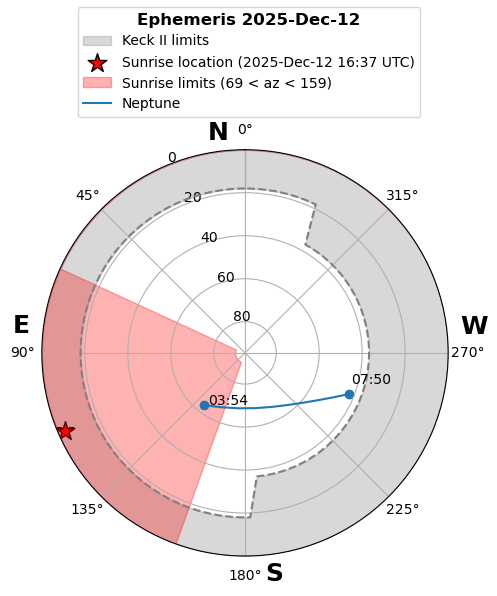

In [201]:
# Plot object trace, with Keck II and sunrise pointing limits

nep_az, nep_el, trace_times = grab_ss_trace('Neptune', keck, sunset_UTC, sunrise_UTC)

fig = make_azel_plot(sunset_UTC, sunset_az, sunrise_UTC, sunrise_az, 
                     nep_az, nep_el, trace_times, obj_label='Neptune')

plt.show()

In [88]:
datestr = 'today' # %b %d
# date = datetime.strptime(datestr, '%b %d')
# date.year


list_of_dtformats_today = ['today', 'tonight', 'now']

# for fmt in list_of_dtformats_today:
#     if (fmt.casefold() in datestr):
#         print('Success')



Success


In [99]:
## Make little function to flexibly parse a datestring




datestr = 'JUNE 9'
print('Test string:', datestr)
parse_datestring(datestr)


Test string: JUNE 9
User-entered observation date: 2026-06-09 00:00:00


(datetime.datetime(2026, 6, 9, 0, 0), '2026')

In [98]:
# datestr = 'today'
# print('Test string:', datestr)
# date, year = parse_datestring(datestr)
# display( date, year )


# datetime.date(year=now.year, month=now.month, day=now.day)

TypeError: unbound method datetime.date() needs an argument

In [112]:
read_solar_ephemeris('2026-01-05')

Multiple rows for the same date. Something went wrong for the 2026-01-05 00:00:00 ephemeris!


0

In [113]:
ephem

NameError: name 'ephem' is not defined

### Match visibility of TOIs

In [22]:
toi_list = pd.read_csv('/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool/exofop_tess(1).csv', 
                       skiprows=2, on_bad_lines='warn')
toi_list

Skipping line 15: expected 28 fields, saw 29
Skipping line 16: expected 28 fields, saw 29
Skipping line 17: expected 28 fields, saw 29
Skipping line 28: expected 28 fields, saw 29
Skipping line 39: expected 28 fields, saw 29
Skipping line 50: expected 28 fields, saw 29
Skipping line 61: expected 28 fields, saw 29
Skipping line 72: expected 28 fields, saw 29
Skipping line 83: expected 28 fields, saw 29
Skipping line 94: expected 28 fields, saw 30
Skipping line 95: expected 28 fields, saw 29
Skipping line 96: expected 28 fields, saw 29
Skipping line 97: expected 28 fields, saw 29
Skipping line 98: expected 28 fields, saw 29
Skipping line 99: expected 28 fields, saw 29
Skipping line 100: expected 28 fields, saw 29
Skipping line 101: expected 28 fields, saw 29
Skipping line 102: expected 28 fields, saw 29
Skipping line 103: expected 28 fields, saw 29
Skipping line 104: expected 28 fields, saw 29
Skipping line 105: expected 28 fields, saw 29
Skipping line 116: expected 28 fields, saw 29
Ski

,TIC ID,TOI,RA,Dec,TFOPWG Disposition,Teff (TOI),log(g) (TOI),Stellar Radius (TOI),Imaging Telescope,Imaging Instrument,...,Imaging Contrast separation,Imaging Date,Stellar Companion Filter Name,Stellar Companion Filter,Stellar Companion notes,Stellar Companion user,Stellar Companion Separation,Stellar Companion Position angle,Stellar Companion Delta mag,Stellar Companion Observation date
0,336732616,103.01,20:49:49.8,-24:25:43.3,KP,6351.0,4.22896,1.400000,Wendelstein,3KK,...,NaN,2018-09-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,336732616,103.01,20:49:49.8,-24:25:43.3,KP,6351.0,4.22896,1.400000,Wendelstein,3KK,...,NaN,2018-09-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,336732616,103.01,20:49:49.8,-24:25:43.3,KP,6351.0,4.22896,1.400000,Gemini,'Alopeke,...,0.5,2021-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,336732616,103.01,20:49:49.8,-24:25:43.3,KP,6351.0,4.22896,1.400000,Gemini,'Alopeke,...,0.5,2021-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,336732616,103.01,20:49:49.8,-24:25:43.3,KP,6351.0,4.22896,1.400000,SOAR,HRCam,...,1,2021-07-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15683,285212983,7616.01,07:59:32,-45:27:13.58,PC,10002.0,4.40497,1.662140,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15684,385796857,7617.01,07:24:00.49,-15:54:40.14,PC,6586.0,3.90808,2.154540,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15685,54391400,7618.01,07:53:24.84,-14:47:58.25,PC,4001.0,4.51347,0.721926,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15686,412386707,7619.01,07:21:56.9,-23:24:50.53,PC,6304.0,3.94553,1.961670,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [244]:
for toi in toi_list['TOI'].unique():
    print('TOI'+str(int(toi)))
    
    
# TOI103.01, 
# TOI105.01, 
# TOI108.01, 
# TOI109.01, 
# TOI113.01, 
# TOI123.01, 
# TOI126.01, 
# TOI132.01, 
# TOI139.01, 
# TOI143.01, 
# TOI148.01, 

TOI103
TOI105
TOI108
TOI109
TOI113
TOI123
TOI126
TOI132
TOI139
TOI143
TOI148
TOI155
TOI166
TOI168
TOI172
TOI177
TOI178
TOI178
TOI178
TOI178
TOI178
TOI181
TOI193
TOI194
TOI197
TOI198
TOI225
TOI228
TOI231
TOI232
TOI233
TOI233
TOI234
TOI237
TOI238
TOI239
TOI240
TOI244
TOI245
TOI247
TOI249
TOI250
TOI251
TOI255
TOI256
TOI256
TOI259
TOI260
TOI261
TOI261
TOI262
TOI263
TOI264
TOI266
TOI266
TOI272
TOI277
TOI278
TOI279
TOI280
TOI287
TOI288
TOI292
TOI294
TOI295
TOI296
TOI297
TOI299
TOI301
TOI303
TOI305
TOI306
TOI307
TOI309
TOI310
TOI314
TOI317
TOI323
TOI325
TOI327
TOI328
TOI329
TOI330
TOI332
TOI333
TOI338
TOI340
TOI341
TOI343
TOI344
TOI345
TOI346
TOI347
TOI348
TOI351
TOI353
TOI356
TOI358
TOI359
TOI362
TOI364
TOI366
TOI369
TOI370
TOI374
TOI376
TOI380
TOI388
TOI391
TOI396
TOI396
TOI396
TOI398
TOI400
TOI402
TOI402
TOI403
TOI406
TOI406
TOI411
TOI411
TOI413
TOI415
TOI423
TOI426
TOI431
TOI431
TOI434
TOI435
TOI437
TOI438
TOI439
TOI442
TOI443
TOI444
TOI445
TOI452
TOI453
TOI455
TOI457
TOI458
TOI461
TOI462

In [24]:
### 

# Read in solar ephemeris for today's date
sunset_UTC, sunset_az, _, _, _, _, sunrise_UTC, sunrise_az, _, _, _, _,  = read_solar_ephemeris()

# Set observatory location
keck = EarthLocation.of_site('Keck')

# Read in (ra, dec) of one TOI host
toi_coord = SkyCoord.from_name("TOI 103.01")
# toi_coord = SkyCoord(toi_list['RA'][0], toi_list['Dec'][0], unit=(u.hourangle, u.deg))

# Convert from (ra, dec) to (az, el) at sunrise from Keck II
toi_coord_azel = toi_coord.transform_to(AltAz(obstime=Time(datetime.strptime(sunrise_UTC, '%Y-%b-%d %H:%M')), location=keck))
toi_az = toi_coord_azel.az.value
toi_el = toi_coord_azel.alt.value
print(toi_az, toi_el)

# Convert from (ra, dec) to (az, el) at sunset from Keck II
toi_coord_azel = toi_coord.transform_to(AltAz(obstime=Time(datetime.strptime(sunset_UTC, '%Y-%b-%d %H:%M')), location=keck))
toi_az = toi_coord_azel.az.value
toi_el = toi_coord_azel.alt.value
print(toi_az, toi_el)


Sunset time: 2025-Dec-16 03:56
Sunrise time: 2025-Dec-16 16:39
104.86310811675108 -46.403291775853845
219.81259830855873 33.77677606543665


In [97]:
# ## Iterate through all unique TOI hosts, check if visible any sunrise of the year
# # multiprocessing

# unique_TOIs = toi_list['TOI'].unique()
# random_tois = np.random.choice(unique_TOIs, 15)
# vis_matrix = np.full((len(unique_TOIs), len(ephem)), False)

# for i, toi_num in tqdm(enumerate(unique_TOIs[:15])):
# # for i, toi_num in tqdm(enumerate(random_TOIs)):
                              
#     # Manually find ra/dec of test TOI
# #     toi_num = random_tois[0]
#     loc = np.where(toi_list['TOI']==toi_num)[0][0] # Find first instance of TOI in table
#     toi_coord = SkyCoord(toi_list['RA'][loc], toi_list['Dec'][loc], unit=(u.hourangle, u.deg))

#     # Try multithreading
#     sunrise_dt_list = [datetime.strptime(ephem['sunrise_UTC'][j], '%Y-%b-%d %H:%M') for j in range(len(ephem))]
#     toi_coord_list = [toi_coord]*len(sunrise_dt_list)
#     keck_site_list = [keck]*len(sunrise_dt_list)

#     # if __name__ == '__main__':
#     vis_matrix_row = []

#     # Initialize pool
#     pool = multiprocessing.Pool(4)

#     # Do multiprocessing for checking if this target is up for each of 365 days of the year
#     for result in pool.starmap(is_target_up_morn_twi, zip(sunrise_dt_list, toi_coord_list, keck_site_list)):
#         vis_matrix_row.append(result)
            
#     # Save as row in visibility matrix
#     vis_matrix[i,:] = vis_matrix_row

    
# # print(len(vis_matrix_row), vis_matrix_row[:5])


In [102]:
## Iterate through all unique TOI hosts, check if visible any sunrise of the year

# Read in TOI list, ephemeris for this year
year = '2027'
toi_list = pd.read_csv(f'{toipath}/exofop_dec-50_sep1.5arcsec.csv', skiprows=2, on_bad_lines='skip')
ephem = pd.read_csv(f'{ephempath}/twilight_ephemerides_keckII_{year}.csv')

# Set observatory location
keck = EarthLocation.of_site('Keck')
    
# Isolate unique TOI identifiers
unique_TOIs = toi_list['TOI'].unique()
print(f'{len(unique_TOIs)} unique TOIs.')

# Set up empty matrix to catch boolean visibility results
vis_matrix = np.full((len(unique_TOIs), len(ephem)), False)

# Pull ~4000-long lists of TOI parameters to iterate over using multiprocess
toi_loc_list = [np.where(toi_list['TOI']==toi_num)[0][0] for toi_num in unique_TOIs]
toi_coord_list = [SkyCoord(toi_list['RA'][loc], toi_list['Dec'][loc], unit=(u.hourangle, u.deg)) for loc in toi_loc_list]
keck_site_list = [keck]*len(toi_loc_list)

sunrise_temp = [datetime.strptime(ephem['sunrise_UTC'][j], '%Y-%b-%d %H:%M') for j in range(len(ephem))]
sunrise_list = [sunrise_temp]*len(toi_loc_list) # shape 4000x365


########################
## Do multiprocessing ##
########################

# Initialize pool
pool = multiprocessing.Pool(4)

# Do multiprocessing for checking if this target is up for each of 365 days of the year
for i, result in enumerate(pool.starmap(multiprocess_toi_visibility, zip(toi_coord_list, sunrise_list, keck_site_list))):
    vis_matrix[i, :] = result
    
pool.close() # are these necessary?
pool.join()



495 unique TOIs.


Number of TOIs never visible in 2025: 0


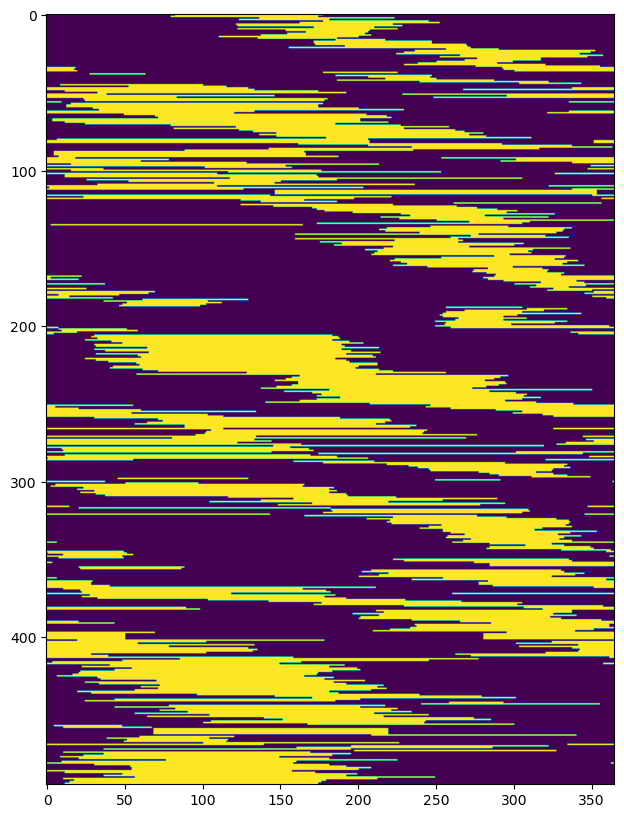

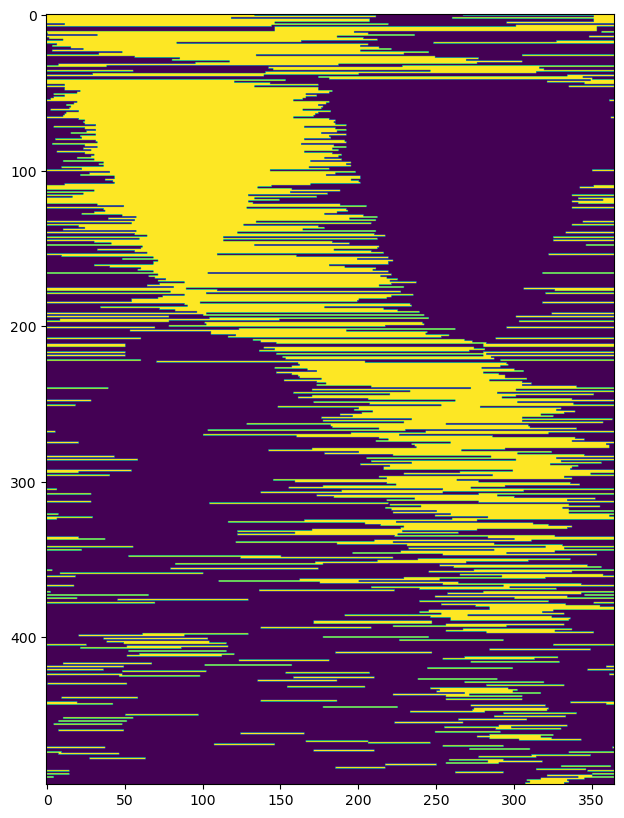

In [110]:
vis_matrix


# Process visibility_matrix, unique_TOIs / random_tois


plt.figure(figsize=(10,10))
plt.imshow(vis_matrix[:,:])

num_days_visible = np.sum(vis_matrix, axis=1)
no_days_visible = num_days_visible==0
print('Number of TOIs never visible in 2025:', np.sum(no_days_visible))



sort_index = np.argsort(num_days_visible)
# print( num_days_visible, np.flip(num_days_visible[sort_index]) )

vis_matrix_sorted = vis_matrix[np.flip(sort_index), :]

plt.figure(figsize=(10,10))
plt.imshow(vis_matrix_sorted[:,:])



In [ ]:
vis_matrix_sorted

In [96]:
# ## Iterate through all unique TOI hosts, check if visible any sunrise of the year

# ##########################
# # Multithreading (jump) ##
# ##########################

# # Read in toi_list, ephem

# # global toi_list, ephem

# year = '2025'
# toi_list = pd.read_csv(f'{toipath}/exofop_tess(1).csv', skiprows=2, on_bad_lines='skip')
# ephem = pd.read_csv(f'{ephempath}/twilight_ephemerides_keckII_{year}.csv')

# unique_TOIs = toi_list['TOI'].unique()
# random_tois = np.random.choice(unique_TOIs, 15)
# # vis_matrix = np.full((len(unique_TOIs), len(ephem)), False)
# # global vis_matrix
# vis_matrix = np.array([])

# print(np.shape(vis_matrix))

# # def toplevel(toi_num, site):
# #     '''
# #     Required globals: toi_list, ephem
# #     '''
    
# #     print('New row:', toi_num)
    
# #     # Manually find ra/dec of test TOI
# #     loc = np.where(toi_list['TOI']==toi_num)[0][0] # Find first instance of TOI in table
# #     toi_coord = SkyCoord(toi_list['RA'][loc], toi_list['Dec'][loc], unit=(u.hourangle, u.deg))


# #     # Iterate through 365 days per year, check twilight visibility

# #     vis_matrix_row = []

# #     for j in range(len(ephem)): # for each day in given year

# #         # Grab
# #         sunrise_dt = datetime.strptime(ephem['sunrise_UTC'][j], '%Y-%b-%d %H:%M')
# #         is_up = is_target_up_morn_twi(sunrise_dt, toi_coord, site=keck)

# #         vis_matrix_row[j] = is_up
        
# # #     out_queue.put(vis_matrix_row)
# # #     vis_matrix = np.append(vis_matrix, vis_matrix_row)
# #     return vis_matrix_row
    

    
# # print(len(vis_matrix_row), vis_matrix_row[:5])

# ###############################
# ## Set up multithreading     ##
# ###############################

# import queue
# import time

# # # Initialize task queue
# # task_queue = multiprocessing.Manager().Queue() # queue.Queue()

# # # Issue all top-level tasks
# # for i, toi_num in enumerate(unique_TOIs[:15]):
# #     task_queue.put((toplevel, (toi_num, year, keck)))

# # # Assume we know the total number of tasks
# # total_tasks = 15 #* len(ephem) # len(unique_TOIs) * len(ephem)

# start_time = time.time()

# # create a thread pool
# with multiprocessing.pool.ThreadPool(total_tasks) as pool:

#     # Set up execution of threads
#     toi_num_list = unique_TOIs[:15]
#     year_list = [year]*15
#     keck_site_list = [keck]*15
    
#     # Execute threads
#     print('Starting starmap')
    
#     for result in pool.starmap(visperday, zip(toi_num_list, year_list, keck_site_list)):
#         vis_matrix = np.append(vis_matrix, result)
#         print(np.shape(vis_matrix))
#     print('Finished starmap', np.shape(vis_matrix), time.time()-start_time)
    
#     # close the pool
#     pool.close()
#     print('Closed', time.time()-start_time)
    
#     # wait for all tasks to be processed
#     pool.join()
#     print('Joined', time.time()-start_time)
        
    
# # result = task_queue.get()
# print('Total execution time:', time.time()-start_time)
# # display(np.shape(result), type(result), result)
# print(np.shape(vis_matrix))


In [ ]:
########################################################
## TEST NESTING MULTIPROCESSING(MULTITHREADING)       ##
########################################################



In [86]:
toi_num_list = unique_TOIs[:15]
year_list = [year]*15
keck_site_list = [keck]*15

print(len(toi_num_list), len(year_list), len(keck_site_list), )

15 15 15


In [35]:
## Iterate through all unique TOI hosts, check if visible any sunrise of the year
## NO MULTIPROCESSING TIMING TEST

unique_TOIs = toi_list['TOI'].unique()
random_tois = np.random.choice(unique_TOIs, 15)
vis_matrix = np.full((len(unique_TOIs), len(ephem)), False)

for i, toi_num in tqdm(enumerate(unique_TOIs)):

    if i > 15: break
                              
    # Manually find ra/dec of test TOI
    loc = np.where(toi_list['TOI']==toi_num)[0][0] # Find first instance of TOI in table
    toi_coord = SkyCoord(toi_list['RA'][loc], toi_list['Dec'][loc], unit=(u.hourangle, u.deg))


    for j in range(len(ephem)): # for each day in given year

        # Grab
        sunrise_dt = datetime.strptime(ephem['sunrise_UTC'][j], '%Y-%b-%d %H:%M')
        is_up = is_target_up_morn_twi(sunrise_dt, toi_coord, site=keck)

        vis_matrix[i][j] = is_up


16it [00:36,  2.28s/it]


In [ ]:
'''
No multiproccessing: ~2.25s/it
Multiprocessing (at date level): ~1.75s/it (twice as fast)
Multiproccessing (at TOI level): ~0.8s/it
Multithreading + multiprocessing: same (~1.75s/it)
'''

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

[102  35  97  99  76  95  58  46  59 101  54  59  47  62  95] [102 101  99  97  95  95  76  62  59  59  58  54  47  46  35]


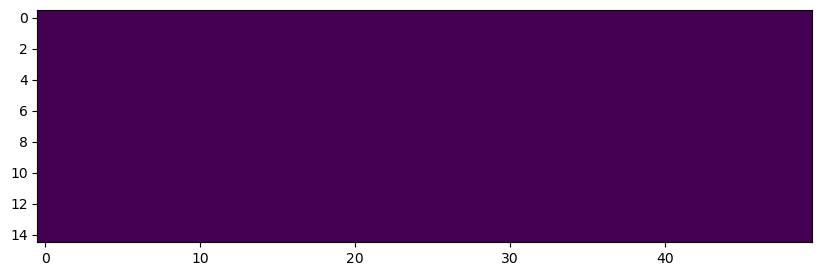

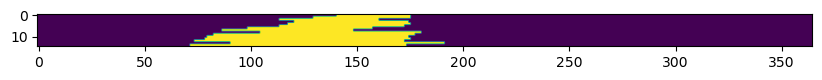

In [34]:
# Process visibility_matrix, unique_TOIs / random_tois


plt.figure(figsize=(10,10))
plt.imshow(vis_matrix[:15,:50])

num_days_visible = np.sum(vis_matrix[:15,:], axis=1)
no_days_visible = num_days_visible==0
display(no_days_visible)



sort_index = np.argsort(num_days_visible)
print( num_days_visible, np.flip(num_days_visible[sort_index]) )

vis_matrix_sorted = vis_matrix[sort_index,:]

plt.figure(figsize=(10,10))
plt.imshow(vis_matrix_sorted[:15,:])



In [ ]:
# Narrow down ExoFOP table to TOIs accessible by Keck for at least 1 night in 2026
# Save that narrowed-down table
# Build visibility matrix for targets
# Make airmass chart for all targets (to sniff check visibility calculation)

In [329]:
# Return list of TOIs visible on a given night
dateloc = 348
datestr = ephem['Date'][dateloc]

up_today = vis_matrix[:, dateloc]
tois_up_tonight = unique_TOIs[up_today]
tois_up_tonight

array([113.01, 123.01, 132.01, 143.01, 148.01, 172.01])

In [321]:
# weights = np.flip( np.arange(1, np.shape(vis_matrix)[1]+1)**2 )
random_tois

array([2867.01, 4499.01, 2453.01, 1749.03, 2015.01, 2993.01, 5327.01,
       1709.01, 7457.01, 2575.01, 2021.01, 2757.01, 6475.01, 1280.01,
       3409.01])

In [313]:
# np.flip(num_days_visible)

# help(np.argsort)

help(multiprocessing)

Help on package multiprocessing:

NAME
    multiprocessing

MODULE REFERENCE
    https://docs.python.org/3.11/library/multiprocessing.html
    
    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

DESCRIPTION
    # Package analogous to 'threading.py' but using processes
    #
    # multiprocessing/__init__.py
    #
    # This package is intended to duplicate the functionality (and much of
    # the API) of threading.py but uses processes instead of threads.  A
    # subpackage 'multiprocessing.dummy' has the same API but is a simple
    # wrapper for 'threading'.
    #
    # Copyright (c) 2006-2008, R Oudkerk
    # Licensed to PSF under a Contributor Agreement.
    #

PACKAGE CONTENTS
    connection
    context
    dummy (

In [270]:
# toi = 'TOI ' + str( toi_list['TOI'].unique()[0] )
toi = toi_list['TOI'].unique()[0]
np.where(toi_list['TOI']==toi)[0][0]

0

In [337]:
# # Make lists of datetime inputs

def is_target_up_morn_twi(sunrise_dt, obj_coord, site):
    '''
    sunrise_dt :: datetime object, datetime of sunrise at site
    obj_coord ::  SkyCoord (ICRS) of target object
    site :: EarthLocation object of observing site
    '''

    # Sample target visibility at 15 minute increments during hour before sunrise
    twilight_samptimes = [sunrise_dt - timedelta(minutes=15*x) for x in range(0,5)]


    # Check if target is within Keck II pointing limits at each sample time
    sampled_visibility = np.full(len(twilight_samptimes), False)

    for j, time in enumerate(twilight_samptimes):

        # What is az/el location of TOI at given time? 
        obj_coord_azel = obj_coord.transform_to(AltAz(obstime=Time(time), location=site))
        obj_az = obj_coord_azel.az.value
        obj_el = obj_coord_azel.alt.value

        # Is it within telescope pointing constraints?
        vis = keckII_pointing_limits(obj_az, obj_el) # returns True/False
        sampled_visibility[j] = vis

    # is object up for at least 3 of the 5 sampled times?
    is_up = (np.sum(sampled_visibility) >= 3.) # True/False -- FIXME is this the right litmus?
    
    return is_up



sunrise_dt = datetime.strptime(ephem['sunrise_UTC'][0], '%Y-%b-%d %H:%M')
is_up = is_target_up_morn_twi(sunrise_dt, toi_coord, site=keck)
is_up

False

In [265]:
sunrise_dt.year

2025